In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_excel(r"D:\testing\BCT_3\data\ipl_players_career_dataset.xlsx")

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   player_id        120 non-null    object 
 1   player_name      120 non-null    object 
 2   team             120 non-null    object 
 3   age              120 non-null    int64  
 4   matches_played   120 non-null    int64  
 5   total_runs       120 non-null    int64  
 6   batting_average  120 non-null    float64
 7   highest_score    120 non-null    int64  
 8   strike_rate      120 non-null    float64
 9   centuries        120 non-null    int64  
 10  half_centuries   120 non-null    int64  
dtypes: float64(2), int64(6), object(3)
memory usage: 10.4+ KB


In [6]:
top_player = df.loc[df["highest_score"].idxmax()]
print(top_player)

player_id                       IPL052
player_name                  Player_52
team               Sunrisers Hyderabad
age                                 28
matches_played                     122
total_runs                        4748
batting_average                  38.92
highest_score                      149
strike_rate                      116.7
centuries                            3
half_centuries                      15
Name: 51, dtype: object


In [7]:
df["batting_average"].mean()

46.630250000000004

In [8]:
df["age"].median()

27.0

In [9]:
df["age"].median()

27.0

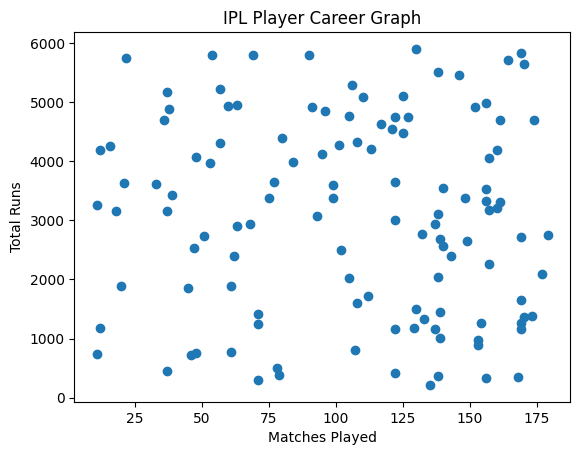

In [10]:
import matplotlib.pyplot as plt

plt.scatter(df["matches_played"], df["total_runs"])

plt.xlabel("Matches Played")
plt.ylabel("Total Runs")
plt.title("IPL Player Career Graph")

plt.show()

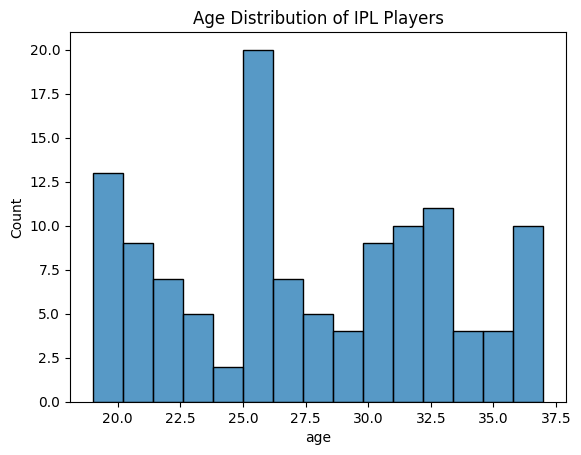

In [11]:
import seaborn as sns

sns.histplot(df["age"], bins=15)

plt.title("Age Distribution of IPL Players")

plt.show()

In [12]:
team_strength = df.groupby("team")[["total_runs","batting_average","strike_rate"]].mean()

team_strength["strength_score"] = (
    team_strength["total_runs"]*0.5 +
    team_strength["batting_average"]*10 +
    team_strength["strike_rate"]*2
)

team_strength = team_strength.sort_values("strength_score", ascending=False)

print(team_strength)

                              total_runs  batting_average  strike_rate  \
team                                                                     
Royal Challengers Bangalore  3673.846154        67.185385   135.805385   
Gujarat Titans               3710.272727        46.232727   154.444545   
Lucknow Super Giants         3042.888889        74.128889   152.407778   
Punjab Kings                 3133.562500        59.168750   136.749375   
Mumbai Indians               3308.818182        41.745455   136.639091   
Rajasthan Royals             3361.500000        35.480000   126.648333   
Delhi Capitals               3041.133333        37.072667   132.837333   
Kolkata Knight Riders        2504.500000        56.997500   136.089167   
Sunrisers Hyderabad          2982.875000        29.353125   136.382500   
Chennai Super Kings          2083.454545        19.819091   137.446364   

                             strength_score  
team                                         
Royal Challengers B

In [13]:
predicted_winner = team_strength.index[0]

print("Predicted IPL 2026 Winner:", predicted_winner)

Predicted IPL 2026 Winner: Royal Challengers Bangalore


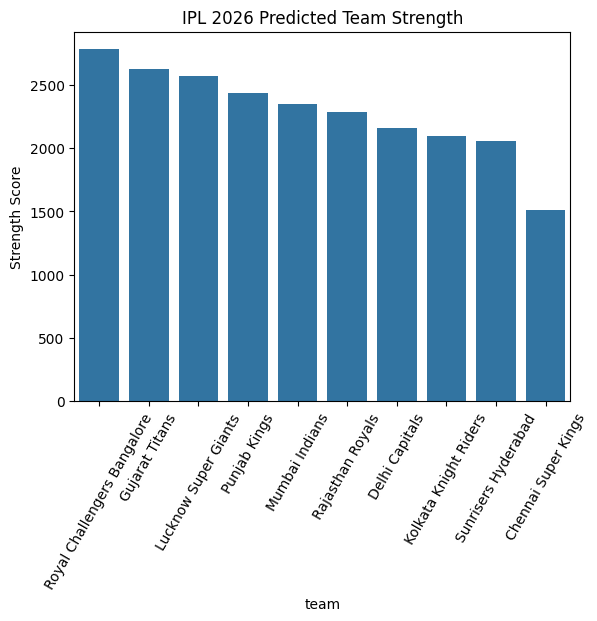

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x=team_strength.index, y=team_strength["strength_score"])

plt.xticks(rotation=60)
plt.title("IPL 2026 Predicted Team Strength")
plt.ylabel("Strength Score")

plt.show()